In [6]:
#Imorting Libraries
import pandas as pd
from datasets import load_dataset
from datetime import datetime
import ast
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

In [7]:
#Data loading
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

In [8]:
#Data CleanUp
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

<Axes: xlabel='count', ylabel='job_location'>

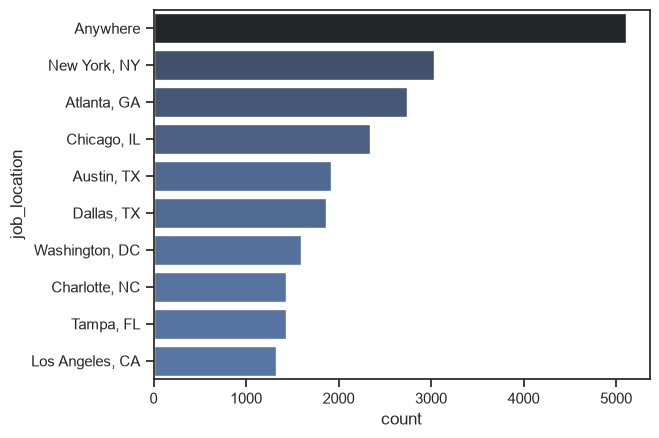

In [9]:
# Set the overall visual style to 'ticks' (adds small axis marks, removes background grid)
sns.set_theme(style="ticks")

# Filter for US Data Analyst jobs only and create a clean, independent copy of the data
df_us_da = df[
    (df["job_title_short"] == "Data Analyst")
    & (df["job_country"] == "United States")
].copy()

# Count jobs per location, take the top 10, and convert it to a new DataFrame
counts_by_location = (
    df_us_da["job_location"].value_counts().head(10).to_frame().copy()
)

# Create a horizontal bar plot with a dark-to-blue gradient palette (dark:b_r)
sns.barplot(
    counts_by_location,
    x="count",
    y="job_location",
    hue="count",
    palette="dark:b_r",
    legend=False,
)


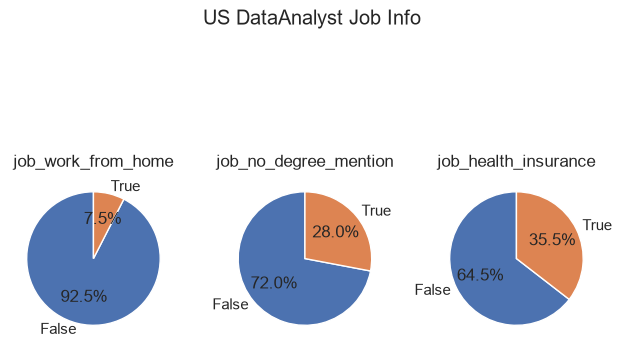

In [10]:
import matplotlib.pyplot as plt

# Create 1 row with 3 side-by-side empty subplots
fig, ax = plt.subplots(1, 3)

# List the specific columns to analyze and plot
to_plot_list = [
    "job_work_from_home",
    "job_no_degree_mention",
    "job_health_insurance",
]

# Loop through columns; 'i' tracks the subplot index, 'to_plot' is the column name
for i, to_plot in enumerate(to_plot_list):
    # Count value frequencies and plot as a pie chart in the current subplot slot (ax[i])
    df_us_da[to_plot].value_counts().plot(
        kind="pie",
        startangle=90,
        autopct="%1.1f%%",
        title=to_plot,
        ax=ax[i],  # 90° rotates start to top; autopct formats percentage text
    )

# Add a single main title above all three pie charts
fig.suptitle("US DataAnalyst Job Info")

# Automatically fix spacing so titles and charts don't overlap
fig.tight_layout()


Text(0.5, 1.0, 'US Top 10 Data Analyst Companies Job Post Counts')

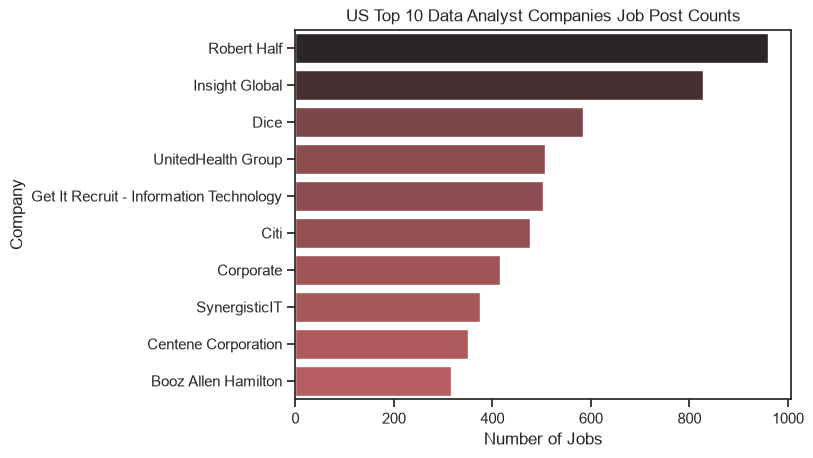

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count job posts per company, take the top 10, and convert it to a new DataFrame
company_counts = df_us_da["company_name"].value_counts().head(10).to_frame().copy()

# Create horizontal bar plot (x='count', y='company_name') with a dark-to-red gradient palette
sns.barplot(
    company_counts,
    x="count",
    y="company_name",
    hue="count",
    palette="dark:r_r",
    legend=False,
)

# Label the horizontal X-axis
plt.xlabel("Number of Jobs")

# Label the vertical Y-axis
plt.ylabel("Company")

# Add the main title at the top of the chart
plt.title("US Top 10 Data Analyst Companies Job Post Counts")


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [ ]:
#counts of job skills per job_title_short for US jobs
df_us = df[df['job_country'] == 'United States'].copy()

df_us_exploded = df_us.explode('job_skills')

df_us_skillsCount = df_us_exploded.groupby(['job_skills','job_title_short']).size().reset_index(name = 'skill_counts')

df_us_skillsCount.sort_values(by='skill_counts', ascending=False, inplace=True)


#Total jobs per job_title_short for US jobs

df_total_jobs = df_us['job_title_short'].value_counts().reset_index(name = 'Total Jobs').copy()


df_skills_pct = df_us_skillsCount.merge(df_total_jobs, on='job_title_short', how='left')
df_skills_pct['skill_percentage'] = (df_skills_pct['skill_counts']/df_skills_pct['Total Jobs'] * 100).round(2)
df_skills_pct.sort_values(by='skill_percentage', ascending=False, inplace=True)

# Plotting the top skills percentage for each job title
fig, ax = plt.subplots(3,1)
job_titles = ['Data Analyst', 'Data Scientist', 'Business Analyst']

'''for i,title in enumerate(job_titles):
    df_plot = df_skills_pct[df_skills_pct['job_title_short'] == title].head()
    df_plot.plot(kind = 'barh', x = 'job_skills',y = 'skill_percentage', ax=ax[i], legend=False, title=title)
    ax[i].set_xlabel('Skill Percentage')
    ax[i].set_ylabel('Job Skills')
    ax[i].set_xlim(0, 100)
    ax[i].invert_yaxis()
    ax[i].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))  # Format x-axis as percentage'''

#plotting the top skills percentage for each job title using seaborn
palette_colors = ['dark:r_r', 'dark:b_r', 'dark:g_r']  # Define a list of colors for each job title
for i, title in enumerate(job_titles):
    df_plot = df_skills_pct[df_skills_pct['job_title_short'] == title].head()
    sns.barplot(data=df_plot, x='skill_percentage', y='job_skills', ax=ax[i], hue = 'skill_counts', palette=palette_colors[i], dodge=False, legend=False)
    ax[i].set_title(title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 100)
    ax[i].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))  # Format x-axis as percentage

    for index,name in enumerate(df_plot['skill_percentage']):
        ax[i].text(name + 1, index, f'{name:.0f}%', va='center')  # Add percentage text to the right of each bar,name + 1 adds a small offset to avoid overlap with the bar,index is used to position the text vertically in line with the bar(name is the skill percentage value for the current bar and index is the position of the bar in the y-axis)

    if i != len(job_titles)-1:
        ax[i].set_xticks([])  # Hide x-axis ticks for all but the last subplot
    if i == len(job_titles)-1:
        ax[i].set_xlabel('Skill Percentage')  # Label x-axis only for the last subplot
fig.suptitle('Top Skills Percentage for US Jobs')
fig.tight_layout(pad = 0.5)



,job_skills,job_title_short,skill_counts
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
1785,vue.js,Business Analyst,1
60,arch,Business Analyst,1
71,asana,Machine Learning Engineer,1
968,no-sql,Machine Learning Engineer,1


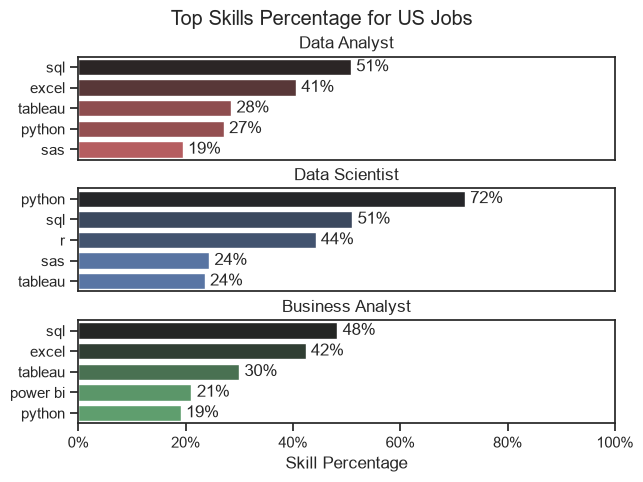